# Bonus: Building the ReAct Loop with LangGraph Primitives

<div align="center">
    <img src="../../images/db_agent.png">
</div>

**Prerequisites:** Section 1 (manual tool calling loop) and Section 2 (`create_agent` abstraction)

---

In Section 1 you wrote the ReAct loop by hand — calling the LLM, checking for tool calls, executing them, feeding results back. In Section 2 you replaced all of that with `create_agent`.

But what is `create_agent` actually doing? The answer is **LangGraph** — a graph execution framework where you define:

- **State** — the shared data structure that flows through the graph
- **Nodes** — Python functions that read and write state
- **Edges** — the routing logic that connects nodes

In this notebook you'll build the same TechHub customer support agent from scratch using these three primitives. By the end, you'll understand exactly what `create_agent` abstracts away, and you'll have the foundation for the custom multi-agent and human-in-the-loop patterns in Sections 3 and 4.

**What you'll learn:**
- How `MessagesState` manages conversation history automatically
- How to write LangGraph nodes as plain Python functions
- How conditional edges implement the "call tools or finish" decision
- How to compile and visualize a `StateGraph`

## Setup

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model
from config import DEFAULT_MODEL

print(f"Using model: {DEFAULT_MODEL}")
llm = init_chat_model(DEFAULT_MODEL)

Using model: anthropic:claude-haiku-4-5


## 1. Import Tools

We'll use the same four TechHub database tools from Section 2 — no need to redefine them.

In [3]:
from tools.database import (
    get_order_status,
    get_order_items,
    get_product_info,
    get_order_item_price,
)

tools = [get_order_status, get_order_items, get_product_info, get_order_item_price]

# Bind the tools to the model so it knows what's available
llm_with_tools = llm.bind_tools(tools)

## 2. State

Every LangGraph graph has a **state** — a typed dictionary that nodes read from and write to.

For a conversational agent, all we need is a list of messages that grows as the conversation progresses. LangGraph ships `MessagesState` for exactly this purpose:

```python
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
```

The `add_messages` reducer is the key detail — instead of replacing the message list on every update, it **appends** new messages. That's how the full conversation history accumulates automatically.

In [4]:
from langgraph.graph import MessagesState

# MessagesState is a TypedDict with a single key: messages
# The add_messages reducer appends new messages rather than overwriting
print(MessagesState.__annotations__)

{'messages': ForwardRef('Annotated[list[AnyMessage], add_messages]', module='langgraph.graph.message')}


## 3. Nodes

Nodes are Python functions with the signature `(state) -> state_update`. Each node receives the current state and returns a dictionary of fields to update.

We need two nodes:
1. **`assistant`** — calls the LLM with the conversation history
2. **`tools`** — executes any tool calls the LLM requested

### Node 1: The Assistant

This node prepends the system prompt and calls the LLM with the full conversation history. It returns the model's response, which `add_messages` appends to the state.

In [5]:
from langchain_core.messages import SystemMessage

SYSTEM_PROMPT = """You are a helpful customer support assistant for TechHub, an electronics store.
You have access to tools to look up order status, product information, and pricing.
Always be professional and concise."""


def assistant(state: MessagesState):
    # Prepend system prompt, then pass the full conversation history
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    # Return the update — add_messages will append response to state["messages"]
    return {"messages": [response]}

### Node 2: The Tool Executor

When the LLM decides to call a tool, something has to actually execute it and format the result as a `ToolMessage`. LangGraph's prebuilt `ToolNode` handles all of that — it reads `tool_calls` off the last message, runs the matching tool, and returns `ToolMessage` objects that get appended to state.

In [6]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

## 4. Edges

Edges define how control flows between nodes.

- **Normal edges** always route to the same target: `tools → assistant`
- **Conditional edges** inspect state and return the name of the next node to visit

After the `assistant` node runs, we need to decide:
- Did the model request tool calls? → route to `tools`
- Did the model give a final answer? → route to `END`

That logic lives in a **routing function**:

In [7]:
def should_continue(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"  # LLM requested tool calls — execute them
    return "end"  # LLM produced a final answer — we're done

## 5. Compile the Graph

Now we wire everything together with `StateGraph`:

1. Add both nodes
2. Add a normal edge from `START` to `assistant` (always start here)
3. Add a conditional edge from `assistant` using `should_continue`
4. Add a normal edge from `tools` back to `assistant` (always return to the model after tool execution)
5. Compile

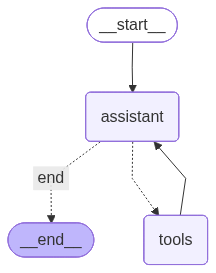

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

# Add edges
builder.add_edge(START, "assistant")  # Always start at the assistant

builder.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "tools": "tools",  # Route to tool_node when the LLM wants to call a tool
        "end": END,  # Route to END when the LLM has a final answer
    },
)

builder.add_edge("tools", "assistant")  # Always return to the assistant after tools

# Compile!
graph = builder.compile()

# Visualize the graph structure
graph

The graph visualization shows the exact loop from Section 1 that we were running manually:

```
START → assistant → tools → assistant → ... → END
```

The conditional edge on `assistant` is the key: if the model returns tool calls, we go to `tools`; otherwise we go to `END`.

## 6. Run the Agent

The compiled graph has the same `.invoke()` interface as `create_agent`. Let's run the same TechHub queries from the earlier sections.

**Example 1: Order status lookup (single tool call)**

In [9]:
from langchain_core.messages import HumanMessage

result = graph.invoke(
    {"messages": [HumanMessage(content="What's the status of order ORD-2024-0123?")]}
)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's the status of order ORD-2024-0123?
================================== Ai Message ==================================

[{'id': 'toolu_01Gtz5CBv2WfJbp5FthmvyBG', 'input': {'order_id': 'ORD-2024-0123'}, 'name': 'get_order_status', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  get_order_status (toolu_01Gtz5CBv2WfJbp5FthmvyBG)
 Call ID: toolu_01Gtz5CBv2WfJbp5FthmvyBG
  Args:
    order_id: ORD-2024-0123
================================= Tool Message =================================
Name: get_order_status

Order ORD-2024-0123:
- Status: Delivered
- Order Date: 2024-12-05
- Shipped Date: 2024-12-07
- Tracking Number: 1Z999AA113527782

================================== Ai Message ==================================

Your order **ORD-2024-0123** has been **Delivered**! Here are the details:

- **Order Date:** December 5, 2024
- **Shipped Date:** December 7, 2024
- **Tracking Number:** 1Z99

**Example 2: Multi-tool query (multiple tool calls across iterations)**

In [10]:
result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="What's the status of order ORD-2024-0123, what was in it, and how much did it cost?"
            )
        ]
    }
)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

What's the status of order ORD-2024-0123, what was in it, and how much did it cost?
================================== Ai Message ==================================

[{'text': "I'll look up the status, items, and pricing for that order.", 'type': 'text'}, {'id': 'toolu_01YWwPX9TVpS9wzjJQMABiAX', 'input': {'order_id': 'ORD-2024-0123'}, 'name': 'get_order_status', 'type': 'tool_use', 'caller': {'type': 'direct'}}, {'id': 'toolu_018RWtQvGZmcgMKqJBADVP16', 'input': {'order_id': 'ORD-2024-0123'}, 'name': 'get_order_items', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  get_order_status (toolu_01YWwPX9TVpS9wzjJQMABiAX)
 Call ID: toolu_01YWwPX9TVpS9wzjJQMABiAX
  Args:
    order_id: ORD-2024-0123
  get_order_items (toolu_018RWtQvGZmcgMKqJBADVP16)
 Call ID: toolu_018RWtQvGZmcgMKqJBADVP16
  Args:
    order_id: ORD-2024-0123
================================= Tool Message ===========================

Notice how the full message history is preserved in `result["messages"]` — the `HumanMessage`, each `AIMessage` (including intermediate tool-call messages), every `ToolMessage` result, and the final answer. This is the `add_messages` reducer at work.

## Key Takeaways

You just built a complete ReAct agent from three primitives:

| Primitive | What it does | In this notebook |
|-----------|-------------|------------------|
| **State** | Shared data structure with reducer logic | `MessagesState` with `add_messages` |
| **Nodes** | Python functions that process state | `assistant` (LLM call) + `ToolNode` (tool execution) |
| **Edges** | Routing logic between nodes | `START → assistant`, `should_continue`, `tools → assistant` |

**This is exactly what `create_agent` builds under the hood** (Section 2). The abstraction is convenient for standard ReAct agents, but these primitives are what you reach for when you need custom behavior:

- **Section 3** (Multi-Agent): Uses `StateGraph` to route between a supervisor and specialized sub-agents
- **Section 4** (HITL): Uses `interrupt()` inside a node to pause the graph and collect human input

Understanding State → Nodes → Edges is the foundation for everything that follows.